In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

c:\Users\ACER\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("gurgaon_properties_missing_value_imputation.csv")

In [4]:
df.shape

(3555, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,on request,sector 103,1.69,9145.021645,3,3,3+,8.0,Relatively New,1670.0,0,0,0,0,0,0,49
1,house,independent,sector 40,5.00,21123.785382,9,9,3+,3.0,Moderately Old,2367.0,0,1,1,0,0,1,83
2,flat,zara aavaas,sector 104,0.20,6644.518272,1,1,1,3.0,Relatively New,301.0,0,0,0,0,0,0,67
3,house,independent,sector 23,2.80,17983.301220,5,5,3+,2.0,Old Property,1557.0,0,0,0,1,0,1,74
4,house,independent,sector 47,5.15,26614.987080,3,9,3+,3.0,Relatively New,1935.0,0,0,1,0,0,1,75


In [6]:
latlong = pd.read_csv("latlong.csv")

In [7]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [8]:
latlong["latitude"] = (
    latlong["coordinates"]
    .str.split(",")
    .str.get(0)
    .str.split("°")
    .str.get(0)
    .astype("float")
)

In [9]:
latlong["longitude"] = (
    latlong["coordinates"]
    .str.split(",")
    .str.get(1)
    .str.split("°")
    .str.get(0)
    .astype("float")
)

In [10]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [11]:
new_df = df.merge(latlong, on='sector')

In [12]:
new_df.dtypes

property_type          str
society                str
sector                 str
price              float64
price_per_sqft     float64
bedRoom              int64
bathroom             int64
balcony                str
floorNum           float64
agePossession          str
built_up_area      float64
study room           int64
servant room         int64
store room           int64
pooja room           int64
others               int64
furnishing_type      int64
luxury_score         int64
coordinates            str
latitude           float64
longitude          float64
dtype: object

In [13]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='str')

In [14]:
group_df = new_df.groupby("sector").mean(numeric_only=True)[["price", "price_per_sqft", "built_up_area", "latitude", "longitude"]]

In [15]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.794599,3056.166667,28.4484,77.0210
manesar,0.962258,4608.077187,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.789967,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.806278,1556.130841,28.4750,76.9715
sector 103,1.495000,7445.789086,1865.428571,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.932200,5936.276566,1566.131800,28.4079,76.9153
sector 93,0.848889,8009.954897,1017.000000,28.4153,76.9326
sector 95,0.477857,5503.492951,2067.821429,28.4172,76.9081


In [16]:
fig = px.scatter_mapbox(
    group_df,
    lat="latitude",
    lon="longitude",
    color="price_per_sqft",
    size="built_up_area",
    color_continuous_scale=px.colors.cyclical.IceFire,
    zoom=10,
    mapbox_style="open-street-map",
    text=group_df.index,
)

In [17]:
fig.show()

In [18]:
new_df.to_csv('data_viz1.csv', index= False)

In [19]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [20]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 103 Gurgaon,flat,on request,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,not available,"Oxirich Chintamanis, Sector 103 Gurgaon, Gurga...",8.0,NaN,1 to 5 Year Old,"['State bank ATM', 'Dr. Hitesh Dawar', 'Bhardw...",Fully furnished property newly constructed wit...,"['3 Wardrobe', '6 Fan', '10 Light', '1 Chimney...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
1,9 Bedroom House for sale in Sector 40 Gurgaon,house,independent,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,"servant room,store room","7777, Sector 40 Gurgaon, Gurgaon, Haryana",3.0,North-West,5 to 10 Year Old,"['Huda city centre metro station', 'Axis bank ...",Its wonderfully made 3bhk on each floor with b...,"['10 Wardrobe', '21 Fan', '1 Exhaust Fan', '9 ...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
2,4 Bedroom House for sale in Sector 66 Gurgaon,house,emaar mgf marbella,NaN,NaN,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500...,4,4,3+,"pooja room,study room,servant room,store room","Sector 66 Gurgaon, Gurgaon, Haryana",3.0,North,0 to 1 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66',...",This is 350 sq.Yd villa in the heart of the ci...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment3 out of 5', 'Safety4 out of 5', ..."
3,1 BHK Flat in Sector 104 Gurgaon,flat,zara aavaas,0.20,6645.0,301.0,Built Up area: 301 (27.96 sq.m.),1,1,1,not available,"Sector 104, Sector 104 Gurgaon, Gurgaon, Haryana",3.0,North-East,undefined,"['Ardee Mall', 'Northern Peripheral Road', 'Mp...",Best in class property available at sector 104...,NaN,NaN,"['Environment4 out of 5', 'Lifestyle4 out of 5..."
4,5 Bedroom House for sale in Ansal Plaza,house,independent,2.80,161849.0,173.0,Plot area 173(16.07 sq.m.)Built Up area: 160 s...,5,5,3+,pooja room,"C Block, Ansal Plaza, Gurgaon, Haryana",2.0,North-East,10+ Year Old,"['HUDA Sector 23 Market', 'Palam triangle', 'P...",Property is in gated society close to market g...,"['6 Wardrobe', '8 Fan', '1 Exhaust Fan', '4 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle5 out of 5..."


In [21]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features', 'sector']]

In [22]:
wordcloud_df.head()

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 103
1,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 40
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 104
3,NaN,sector 23
4,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 47


In [23]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [24]:
main

['Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Park',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Rain Water Harvesting',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Centrally Air Conditioned',
 'Water purifier',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Low Density Society',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Feng Shui / Vaastu Compliant',
 'Private G

In [25]:
from wordcloud import WordCloud

In [26]:
feature_text = ' '.join(main)

In [27]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [28]:
feature_text

'Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Feng Shui / Vaastu Compliant Private Garden / Terrace High Ceiling Height Maintenance Staff Water Storage Separate entry for servant room No open drainage around Park Natural Light Airy Rooms Spacious Interiors Rain Water Harvesting Security / Fire Alarm Feng Shui / Vaastu Compliant Centrally Air Conditioned Water purifier High Ceiling Height Maintenance Staff Water Storage Separate entry for servant room No open drainage around Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natural Light Internet/wi-fi connectivity Airy Rooms Low Density Society Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Feng Shui / Vaastu Compliant Private Garden / Terrace False Ceiling Lighting Water Storage No open drainage around Recently Renovated Piped-gas Visitor Parking Park Natural Light Airy Rooms Spacious Interiors Lo

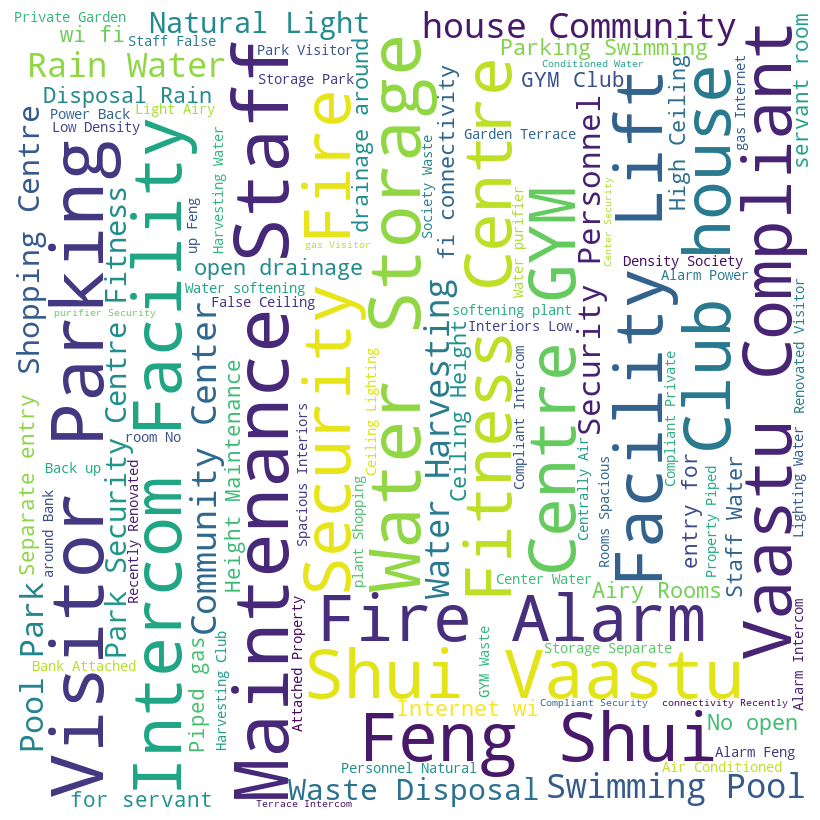

In [29]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    stopwords=set(["s"]),  # Any stopwords you'd like to exclude
    min_font_size=10,
).generate(feature_text)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [30]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names="property_type",
    values="price_per_sqft",
    parents="bedRoom",
    title="Sample Sunburst Chart",
)
fig.show()

In [35]:
fig = px.scatter(
    df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price"
)

fig.show()

In [32]:
temp_df = df[df["bedRoom"] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x="bedRoom", y="price", title="BHK Price Range")

# Show the plot
fig.show()

In [34]:
new_df['sector'].unique().tolist().insert(0, 'overall')

In [37]:
fig2 = px.pie(df, names = 'bedRoom', title = 'Total Bill Amount by Day')

fig2.show()